[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/giuliofranzese/Cajal/blob/main/infosedd/infosedd_lecture.ipynb)

# InfoSEDD Lecture: Information Estimation with Discrete Diffusion

**A guided tour through synthetic experiments and motif selection**

---

This notebook walks through the core ideas behind **InfoSEDD** — a neural mutual information estimator based on score-based discrete diffusion — using a controlled synthetic experiment and a real-world motif selection application on genomic data.

## Outline

1. **Theory**: Mutual information, discrete diffusion, and score-based estimation
2. **Synthetic Experiment**: Estimating MI on a known distribution
3. **Motif Selection**: Sliding-window MI on DNA promoter sequences

## Dependencies and repository
First, let's clone the InfoSEDD github repository and install the dependencies!

In [1]:
%%bash

rm -r mutinfo-diffusion/

git clone https://github.com/AlbertoForesti/mutinfo-diffusion
cd mutinfo-diffusion
uv pip install -e .

rm: cannot remove 'mutinfo-diffusion/': No such file or directory
Cloning into 'mutinfo-diffusion'...
Using Python 3.12.13 environment at: /usr
Resolved 103 packages in 10.74s
Prepared 42 packages in 53.00s
Uninstalled 28 packages in 1.20s
Installed 42 packages in 507ms
 + biopython==1.85
 + causal-conv1d==1.3.0.post1+cu122torch2.2cxx11abifalse (from https://github.com/Dao-AILab/causal-conv1d/releases/download/v1.3.0.post1/causal_conv1d-1.3.0.post1+cu122torch2.2cxx11abiFALSE-cp312-cp312-linux_x86_64.whl)
 - datasets==4.0.0
 + datasets==3.1.0
 + docker-pycreds==0.4.0
 - einops==0.8.2
 + einops==0.8.0
 + flash-attn==2.6.0.post1+cu122torch2.2cxx11abifalse (from https://github.com/Dao-AILab/flash-attention/releases/download/v2.6.0.post1/flash_attn-2.6.0.post1+cu122torch2.2cxx11abiFALSE-cp312-cp312-linux_x86_64.whl)
 - fsspec==2025.3.0
 + fsspec==2024.9.0
 - huggingface-hub==1.8.0
 + huggingface-hub==0.36.2
 + hydra-core==1.3.2
 + infosedd==0.1.0 (from file:///content/mutinfo-diffusion)
 + 

# IMPORTANT
If you are on colab you have to go to runtime > restart session to update synchronise python dependencies, otherwise it will fail

## 0. Setup & Imports

In [1]:
import sys
import os

# Add the synthetic and real-data modules to the path
synthetic_path = os.path.abspath("mutinfo-diffusion/infosedd_synthetic")
real_data_path = os.path.abspath("mutinfo-diffusion/infosedd_real_data")
if synthetic_path not in sys.path:
    sys.path.insert(0, synthetic_path)
if real_data_path not in sys.path:
    sys.path.insert(0, real_data_path)

import torch
import numpy as np
import matplotlib.pyplot as plt
import pytorch_lightning as pl
from omegaconf import OmegaConf

# Set seeds for reproducibility
pl.seed_everything(42)
torch.manual_seed(42)
np.random.seed(42)

print("Imports OK")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

INFO:lightning_fabric.utilities.seed:Seed set to 42


Imports OK
PyTorch: 2.2.2+cu121
CUDA available: True
GPU: Tesla T4


---

## 1. Theory: Mutual Information & Discrete Diffusion

### 1.1 Mutual Information

Mutual information (MI) quantifies how much knowing one random variable reduces uncertainty about another:

$$I(X; Y) = \sum_{x,y} p(x,y) \log \frac{p(x,y)}{p(x)p(y)} = D_{KL}\big(p(x,y) \,\|\, p(x)p(y)\big)$$

Key properties:
- $I(X;Y) \geq 0$, with equality iff $X \perp Y$
- Symmetric: $I(X;Y) = I(Y;X)$
- Invariant to invertible transformations

### 1.2 Why is MI estimation hard?

For **discrete, high-dimensional** data (text, DNA sequences, categorical features), computing MI requires:
1. Estimating the joint distribution $p(x,y)$ — exponentially large table
2. Estimating marginals $p(x)$ and $p(y)$
3. Both suffer from the **curse of dimensionality**

Classical estimators (kNN, binning) fail in high dimensions. Neural estimators (MINE, NWJ, SMILE) use variational bounds but suffer from high variance or bias.

### 1.3 InfoSEDD: Score-Based MI Estimation

InfoSEDD reframes MI estimation through **discrete diffusion**. The key insight:

> The KL divergence between the joint and product of marginals can be expressed as an integral over a diffusion trajectory of **score functions**.

**The diffusion process**: Starting from data $X_0$, we gradually corrupt it via a continuous-time Markov chain with rate matrix $Q$. Following the [SEDD](https://arxiv.org/abs/2310.16834) convention, we treat the probability distribution as a **column vector** $p_t$ evolving as:

$$\frac{d}{dt} p_t = Q \, p_t$$

where $Q$ is the rate matrix (columns sum to zero, off-diagonal entries $Q_{ij} \geq 0$). The solution is $p_t = e^{Qt} p_0$.

For the **absorbing graph** (used in InfoSEDD, following the [SEDD](https://arxiv.org/abs/2310.16834) convention), the state space is $\{1, 2, \ldots, K, \text{M}\}$ where M is the absorbing (mask) state. The rate matrix is:

$$Q = \begin{pmatrix}
-1 & 0 & \cdots & 0 & 0 \\
0 & -1 & \cdots & 0 & 0 \\
\vdots & \vdots & \ddots & \vdots & \vdots \\
0 & 0 & \cdots & -1 & 0 \\
1 & 1 & \cdots & 1 & 0
\end{pmatrix}$$

Each non-mask token transitions to the mask state at rate 1. Once masked, it stays masked forever (the last column is all zeros). The transition probability at noise level $\sigma$ is:

$$p(x_t = k \mid x_0 = i) = \begin{cases} e^{-\sigma} & \text{if } k = i \\ 1 - e^{-\sigma} & \text{if } k = \text{M} \\ 0 & \text{otherwise} \end{cases}$$

**The score function** is defined as the ratio of perturbed probabilities:

$$s_\theta(y, x_t, \sigma) \approx \frac{p_t(y)}{p_t(x_t)}$$

A neural network is trained to predict this score via a **score entropy** loss. Once trained, MI is estimated by comparing the **joint score** vs. the **marginal scores** through a KL divergence:

$$I(X;Y) \approx \int_0^1 \! D_{KL}\!\left(p_t^{\text{joint}} \,\|\, p_t^{\text{marginal}}\right) \sigma(t)dt$$

### 1.4 Two Variants

Using joint score and marginal score is not the only way to compute MI, as it can also be expressed using conditional distributions.

| Variant | Description | KL Expression |
|---------|-------------|---------------|
| **InfoSEDD-J** (joint) | Estimates $I(X;Y)$ by comparing joint vs. product-of-marginals scores | $D_{KL}(P(X,Y) \parallel P(X)P(Y))$ |
| **InfoSEDD-C** (conditional) | Estimates $I(X;Y)$ by comparing conditional vs. marginal scores | $\mathbb{E}_{P(Y)}[D_{KL}(P(X \mid Y) \parallel P(X))]$ |

Both converge to the same true MI value but have different properties. Notably, the j variant, given two random vectors X and Y, allows us to compute the MI between any subsets of X and Y with a single training run. This property unlocks the motif finding applications that we will discover later.

### 1.5 Visualizing the Absorbing Diffusion Process

Let's visualize how the absorbing noise process corrupts a discrete DNA sequence:

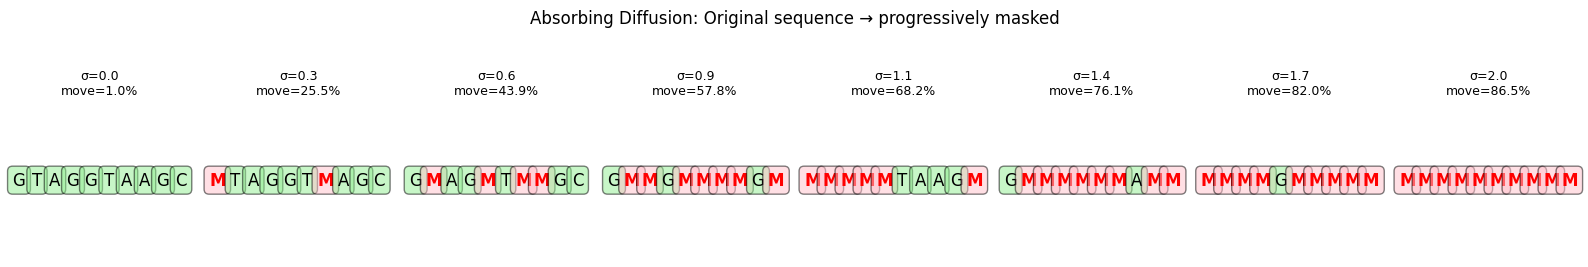

In [2]:
def visualize_absorbing_process(seq_length=10, alphabet_size=4, n_sigmas=8):
    """Visualize how the absorbing diffusion process corrupts a sequence."""
    np.random.seed(42)

    # Generate a random sequence (1D array)
    original = np.random.randint(0, alphabet_size, size=seq_length)

    # Noise levels (sigma values)
    sigmas = np.linspace(0.01, 2.0, n_sigmas)

    fig, axes = plt.subplots(1, n_sigmas, figsize=(16, 2.5))
    chars = ['A', 'C', 'G', 'T']

    for i, sigma in enumerate(sigmas):
        move_chance = 1 - np.exp(-sigma)
        move_indices = np.random.rand(seq_length) < move_chance
        perturbed = np.where(move_indices, -1, original)  # -1 = mask

        ax = axes[i]
        for j, val in enumerate(perturbed):
            if int(val) == -1:  # Compare scalar, not array
                ax.text(j, 0.5, 'M', ha='center', va='center', fontsize=12,
                       color='red', fontweight='bold',
                       bbox=dict(boxstyle='round', facecolor='pink', alpha=0.5))
            else:
                ax.text(j, 0.5, chars[int(val)], ha='center', va='center', fontsize=12,
                       color='black',
                       bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

        ax.set_xlim(-0.5, seq_length - 0.5)
        ax.set_ylim(0, 1)
        ax.set_title(f'σ={sigma:.1f}\nmove={move_chance:.1%}', fontsize=9)
        ax.axis('off')

    plt.suptitle('Absorbing Diffusion: Original sequence → progressively masked', fontsize=12, y=1.05)
    plt.tight_layout()
    plt.show()

visualize_absorbing_process()

---

## 2. Synthetic Experiment: MI Estimation at MI = 10

We now run a controlled experiment where we **know the true MI** and verify that InfoSEDD recovers it.

The synthetic data generator creates distributions with **pairwise dependencies** between tokens, with a tunable target MI value. It uses an evolutionary algorithm to find joint distributions with the desired MI.

We fix **MI = 10 nats** and **seq_length = 10**, training for **10,000 steps**.

In [ ]:
from infosedd_synthetic.datamodule import SyntheticDataModule
from infosedd_synthetic.mi_estimator import MIEstimator

true_mi = 10

print(f"Synthetic Experiment Configuration:")
print(f"  True MI: {true_mi} nats")
print(f"  Sequence length: 10")
print(f"  Alphabet size: 4")
print(f"  Training steps: 10,000")
print(f"  Variant: InfoSEDD-J")

In [ ]:
pl.seed_everything(42)

cfg = OmegaConf.create({
    "estimator": "infosedd",
    "seq_length": 10,
    "batch_size": 1024,
    "alphabet_size": 4,
    "mutual_information": 10.0,
    "n_generations": 1000,
    "n_samples": 100000,
    "sampling_eps": 0.001,
    "graph": "absorb",
    "noise": "loglinear",
    "is_parametric_marginal": False,
    "use_marginal_flag": False,
    "normalize": False,
    "noise_rv": None,
    "variant": "j",
    "dropout": 0,
    "resnet_block_groups": 8,
    "sigma_dim": 40,
    "init_dim": 80,
    "scaling_factor": None,
    "dim_mults": [1, 1],
    "load_path": None,
    "save_dataset": False,
    "save_root": ".",
})

dm = SyntheticDataModule(cfg)
mdl = MIEstimator(cfg)

trainer = pl.Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    max_steps=10000,
    val_check_interval=1000,
    check_val_every_n_epoch=None,
    logger=False,
    enable_progress_bar=True,
    limit_val_batches=1.0,
)

trainer.fit(mdl, dm)
print("\n✅ Training complete!")

In [ ]:
# Plot MI estimation trend over training
mi_history = mdl.results["mi_history"]
steps = [h["epoch"] for h in mi_history]
mi_means = [h["mean_mi"] for h in mi_history]
mi_stds = [h["std_mi"] for h in mi_history]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(steps, mi_means, 'b-o', markersize=4, label='InfoSEDD estimate')
ax.fill_between(steps,
                [m - s for m, s in zip(mi_means, mi_stds)],
                [m + s for m, s in zip(mi_means, mi_stds)],
                alpha=0.2, color='blue', label='±1 std')
ax.axhline(y=true_mi, color='r', linestyle='--', linewidth=2,
           label=f'True MI = {true_mi} nats')
ax.set_xlabel('Training Step')
ax.set_ylabel('Mutual Information (nats)')
ax.set_title(f'InfoSEDD MI Estimation (True MI = {true_mi} nats)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary table
print(f"\n{'Step':>8} {'Estimated MI':>14} {'Std':>8} {'Error':>8} {'Error %':>8}")
print("-" * 54)
for h in mi_history:
    step = h['epoch']
    est = h['mean_mi']
    std = h['std_mi']
    err = abs(est - true_mi)
    pct = err / true_mi * 100
    print(f"{step:8d} {est:14.3f} {std:8.3f} {err:8.3f} {pct:7.1f}%")

---

## 3. Motif Selection: Finding Informative DNA Regions

### 3.1 The Biological Problem

In genomics, **transcription factor binding motifs** are short DNA sequences (6-20 bp) that regulate gene expression. Finding these motifs is like finding needles in a haystack — the genome is millions of bases long, but motifs are tiny.

**InfoSEDD approach**: Train a diffusion model on promoter sequences, then slide a window across the sequence and measure how much MI each window contributes. Windows with high MI contain informative motifs.

### 3.2 How It Works: The InfoSEDD Pipeline

Instead of relying on traditional heuristic motif scanners, InfoSEDD formulates motif discovery as an information-theoretic masking task. The mechanism operates through a systematic, four-step pipeline:

1. **Model Training:** First, we train (or fine-tune) a discrete diffusion model on the complete dataset, learning the joint distribution of the full DNA sequences and their corresponding biological labels.
2. **Sliding Window & Masking:** To isolate the importance of specific regions, we slide a fixed-length window across the sequence. At each position $i$, we isolate the window $[i, i + \text{box\_length})$ and **mask** every other element in the entire sequence.
3. **Mutual Information Scoring:** For each isolated window, we use the trained model to compute the Mutual Information (MI). This step quantitatively measures how much predictive information that specific, unmasked sequence patch contains.
4. **Motif Identification:** Finally, we plot the MI scores against their starting positions $i$. The regions that yield the largest MI scores emerge as distinct peaks on the plot, successfully localizing the most relevant and informative biological motifs.

### 3.3 Dataset: Arabidopsis Promoters

The experiment uses the **Arabidopsis thaliana** promoter dataset from [Solovyev & Umarov (2017)](https://github.com/solovictor/CNNPromoterData):
- **Promoters**: 251-bp sequences around transcription start sites (from EPDnew)
- **Non-promoters**: matched genomic background sequences (random fragments after first exons)
- **Goal**: Find which positions contain the most predictive information about promoter status

### 3.4 Data Acquisition

We download the FASTA files directly from the CNNPromoterData repository:

In [3]:
%%bash
# Download Arabidopsis promoter and non-promoter FASTA files
# Source: https://github.com/solovictor/CNNPromoterData
# Reference: Umarov R, Solovyev V. Recognition of Prokaryotic and Eukaryotic Promoters
#            Using Convolutional Deep Learning Neural Networks. PLoS One, 2017.

DATA_DIR="data"
mkdir -p "$DATA_DIR"

PROMOTER_URL="https://raw.githubusercontent.com/solovictor/CNNPromoterData/master/Arabidopsis_tata.fa"
NON_PROMOTER_URL="https://raw.githubusercontent.com/solovictor/CNNPromoterData/master/Arabidopsis_non_prom_big.fa"

echo "Downloading Arabidopsis promoter sequences..."
curl -sL -o "$DATA_DIR/Arabidopsis_tata.fa" "$PROMOTER_URL"
echo "  → $(wc -l < "$DATA_DIR/Arabidopsis_tata.fa") lines"

echo "Downloading Arabidopsis non-promoter sequences..."
curl -sL -o "$DATA_DIR/Arabidopsis_non_prom_big.fa" "$NON_PROMOTER_URL"
echo "  → $(wc -l < "$DATA_DIR/Arabidopsis_non_prom_big.fa") lines"

echo ""
echo "Download complete. Files:"
ls -lh "$DATA_DIR"/*.fa

  → 8982 lines
  → 22918 lines

Download complete. Files:
-rw-r--r-- 1 root root 3.8M Apr 10 15:33 data/Arabidopsis_non_prom_big.fa
-rw-r--r-- 1 root root 468K Apr 10 15:33 data/Arabidopsis_tata.fa


### 3.5 Building the Dataset

Parse the FASTA files and create a balanced, train/val/test-split dataset saved to disk. This dataset will be loaded and tokenized by the real-data pipeline.

In [ ]:
import os
import random
from datasets import Dataset, DatasetDict
import pandas as pd
from typing import List, Dict

def parse_non_promoter_fasta(file_path: str) -> List[Dict]:
    """Parse non-promoter FASTA file."""
    sequences = []
    current_header = ""
    current_seq = ""

    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if current_header and current_seq:
                    gene_id = ""
                    if "gene_id:" in current_header:
                        try:
                            gene_id = current_header.split("gene_id:")[1].split()[0].strip()
                        except:
                            pass
                    description = current_header
                    if "[" in description:
                        description = description.split("[")[0].strip()
                    sequences.append({
                        'seq': current_seq,
                        'description': description,
                        'gene_id': gene_id,
                        'is_promoter': 0,
                        'label': 0
                    })
                current_header = line[1:]
                current_seq = ""
            else:
                current_seq += line

        if current_header and current_seq:
            gene_id = ""
            if "gene_id:" in current_header:
                try:
                    gene_id = current_header.split("gene_id:")[1].split()[0].strip()
                except:
                    pass
            description = current_header
            if "[" in description:
                description = description.split("[")[0].strip()
            sequences.append({
                'seq': current_seq,
                'description': description,
                'gene_id': gene_id,
                'is_promoter': 0,
                'label': 0
            })

    return sequences

def parse_promoter_fasta(file_path: str) -> List[Dict]:
    """Parse promoter FASTA file."""
    sequences = []
    current_header = ""
    current_seq = ""

    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if current_header and current_seq:
                    parts = current_header.split()
                    fp_id = parts[0] if len(parts) > 0 else ""
                    gene_id = parts[1] if len(parts) > 1 else ""
                    range_info = ' '.join(parts[2:]) if len(parts) > 2 else ""
                    sequences.append({
                        'seq': current_seq,
                        'fp_id': fp_id,
                        'gene_id': gene_id,
                        'range_info': range_info,
                        'is_promoter': 1,
                        'label': 1
                    })
                current_header = line[1:]
                current_seq = ""
            else:
                current_seq += line

        if current_header and current_seq:
            parts = current_header.split()
            fp_id = parts[0] if len(parts) > 0 else ""
            gene_id = parts[1] if len(parts) > 1 else ""
            range_info = ' '.join(parts[2:]) if len(parts) > 2 else ""
            sequences.append({
                'seq': current_seq,
                'fp_id': fp_id,
                'gene_id': gene_id,
                'range_info': range_info,
                'is_promoter': 1,
                'label': 1
            })

    return sequences

def create_dna_promoter_dataset(promoter_file: str, non_promoter_file: str,
                               output_dir=None, train_split=0.8,
                               val_split=0.1, test_split=0.1, seed=42):
    """Create a balanced HuggingFace dataset from promoter and non-promoter files."""
    if not os.path.exists(promoter_file):
        raise FileNotFoundError(f"Promoter file not found: {promoter_file}")
    if not os.path.exists(non_promoter_file):
        raise FileNotFoundError(f"Non-promoter file not found: {non_promoter_file}")

    promoters = parse_promoter_fasta(promoter_file)
    non_promoters = parse_non_promoter_fasta(non_promoter_file)

    print(f"Found {len(promoters)} promoters and {len(non_promoters)} non-promoters")

    min_size = min(len(promoters), len(non_promoters))
    random.seed(seed)
    sampled_promoters = random.sample(promoters, min_size)
    sampled_non_promoters = random.sample(non_promoters, min_size)

    all_data = sampled_promoters + sampled_non_promoters
    random.shuffle(all_data)

    df = pd.DataFrame(all_data)

    train_size = int(len(df) * train_split)
    val_size = int(len(df) * val_split)

    train_df = df[:train_size]
    val_df = df[train_size:train_size+val_size]
    test_df = df[train_size+val_size:]

    dataset_dict = DatasetDict({
        'train': Dataset.from_pandas(train_df),
        'validation': Dataset.from_pandas(val_df),
        'test': Dataset.from_pandas(test_df)
    })

    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        dataset_dict.save_to_disk(output_dir)
        print(f"Dataset saved to {output_dir}")

    return dataset_dict

# Create the dataset from downloaded FASTA files
promoter_file = "data/Arabidopsis_tata.fa"
non_promoter_file = "data/Arabidopsis_non_prom_big.fa"
output_dir = "data/Genomic_Arabidopsis_promoter_dataset_tata"

dataset = create_dna_promoter_dataset(
    promoter_file=promoter_file,
    non_promoter_file=non_promoter_file,
    output_dir=output_dir
)

print(f"\nTrain: {len(dataset['train'])} examples")
print(f"Validation: {len(dataset['validation'])} examples")
print(f"Test: {len(dataset['test'])} examples")

# Check class balance
train_promoters = sum(dataset['train']['is_promoter'])
train_non_promoters = len(dataset['train']) - train_promoters
print(f"\nClass balance in training set:")
print(f"Promoters: {train_promoters} ({train_promoters/len(dataset['train'])*100:.1f}%)")
print(f"Non-promoters: {train_non_promoters} ({train_non_promoters/len(dataset['train'])*100:.1f}%)")

### 3.6 Training the InfoSEDD Model

We use the real-data pipeline from `infosedd_real_data`. The pipeline handles:
- Tokenization via a pretrained Caduceus tokenizer (loaded via `get_tokenizer`)
- Label encoding (binary label prepended as DNA characters)
- Dataset loading, batching, and wrapping

The `get_dataset()` function in `dataloader.py` handles the Genomic dataset specially: it encodes the label in base-4 (A/C/G/T), prepends it to the sequence, and tokenizes the combined string.

⚠️ Training in this section can take a long time on student machines. **Recommended workflow:** use a pre-trained checkpoint for Section 3.7.

Recommended checkpoint download:
`wget -O tata_caduceus.ckpt "https://huggingface.co/buckets/AlbertoForesti/infosedd/resolve/tata_caduceus.ckpt?download=true"`

In [5]:
# Section 3.6 Setup: Imports, Resolvers, and Variables

import os
import torch
import hydra
from hydra import compose, initialize_config_dir
from hydra.utils import instantiate
import lightning as L
from omegaconf import OmegaConf

from infosedd_real_data.diffusion import Diffusion
from infosedd_real_data.dataloader import get_dataloaders, get_tokenizer

# Register custom Hydra resolvers (from main.py)
OmegaConf.register_new_resolver("cwd", os.getcwd, replace=True)
OmegaConf.register_new_resolver("device_count", torch.cuda.device_count, replace=True)
OmegaConf.register_new_resolver("eval", eval, replace=True)
OmegaConf.register_new_resolver("div_up", lambda x, y: (x + y - 1) // y, replace=True)

# Data configuration
data_path = r"data/Genomic_Arabidopsis_promoter_dataset_tata"

# Pretrained DNA discrete diffusion model
model_path = "kuleshov-group/caduceus-ph_seqlen-1k_d_model-256_n_layer-4_lr-8e-3"

SKIP_TRAINING = True  # Set to False to enable training

print("✅ Section 3.6 setup complete")
print(f"   Data path: {data_path}")
print(f"   Model path: {model_path}")

✅ Section 3.6 setup complete
   Data path: data/Genomic_Arabidopsis_promoter_dataset_tata
   Model path: kuleshov-group/caduceus-ph_seqlen-1k_d_model-256_n_layer-4_lr-8e-3


In [ ]:
# Load config from repo using Hydra compose API
config_dir = os.path.abspath("mutinfo-diffusion/infosedd_real_data/configs")
with initialize_config_dir(version_base=None, config_dir=config_dir):
    config = compose(
        config_name="config_genomics",
        overrides=[
            "model=caduceus1k",
            "backbone=caduceus",
            f"data_path={data_path}",
            f"eval.checkpoint_path={model_path}",
            "strategy=single_device"
        ]
    )

# Step 1: Create tokenizer
tokenizer = get_tokenizer(config)

# Step 2: Create dataloaders
train_ds, valid_ds = get_dataloaders(config, tokenizer, valid_seed=config.seed)

# Step 3: Set var_indices and limit_val_batches
OmegaConf.update(config, "trainer.limit_val_batches", config.eval.mc_estimates, force_add=True)
OmegaConf.update(config, "mutinfo.var_indices", train_ds.dataset.var_indices, force_add=True)

# Step 4: Create model
model = Diffusion(config, tokenizer=valid_ds.tokenizer)

# Step 5: Create trainer
trainer = instantiate(
    config.trainer,
    default_root_dir=os.getcwd(),
    callbacks=[],
    strategy=instantiate(config.strategy),
    logger=None
)

# Step 6: Train or download model
if SKIP_TRAINING:
    print("\n⚠️ Skipping training as per SKIP_TRAINING=True. Download the model from huggingface instead with section 3.6-b!")
else:
    trainer.fit(model, train_ds, valid_ds)
    print("\n✅ Model training complete!")
    print(f"Final MI estimate: {model.valid_mutinfo}")

## 3.6-b Donwload model from huggingface
I already did the training for you, just run the following cell to download the model!

In [ ]:
%%bash
wget -O tata_caduceus.ckpt "https://huggingface.co/buckets/AlbertoForesti/infosedd/resolve/tata_caduceus.ckpt?download=true"

### 3.7 Sliding Window Motif Selection

With the trained model, we now slide a window across the sequence and measure MI at each position. This reveals which regions carry the most information about promoter status.

If Section 3.6 training is too slow, download and use the recommended checkpoint from the HF bucket instead of waiting for local training to finish.

The procedure:
1. For each window position `i`, create a masked version of the data where positions `[i, i+box_length)` are replaced with the mask token
2. Run MI estimation via Monte Carlo sampling
3. Record MI estimate and standard deviation
4. Plot MI vs. position — peaks indicate informative motifs

In [58]:
# Section 3.7 Setup: Imports, Resolvers, and Variables
# This section is independent - you can run it without running 3.6

import os
import gc
import torch
from hydra import compose, initialize_config_dir
from hydra.utils import instantiate
from omegaconf import OmegaConf
from copy import deepcopy

from infosedd_real_data.diffusion import Diffusion
from infosedd_real_data.dataloader import get_dataloaders, get_tokenizer, InfiniteDataLoader

# Register custom Hydra resolvers (from main.py)
OmegaConf.register_new_resolver("cwd", os.getcwd, replace=True)
OmegaConf.register_new_resolver("device_count", torch.cuda.device_count, replace=True)
OmegaConf.register_new_resolver("eval", eval, replace=True)
OmegaConf.register_new_resolver("div_up", lambda x, y: (x + y - 1) // y, replace=True)

# ========================================================================
# USER CONFIGURATION: Edit these paths as needed
# ========================================================================

# Recommended pre-trained checkpoint (use this if 3.6 training is too slow)
checkpoint_download_url = "https://huggingface.co/buckets/AlbertoForesti/infosedd/resolve/tata_caduceus.ckpt?download=true"

# Checkpoint from training (can be from 3.6 or any other trained model)
checkpoint_path = "tata_caduceus.ckpt"

# Data path for motif selection (should match training data)
data_path = r"data/Genomic_Arabidopsis_promoter_dataset_tata"

# Motif selection output path
motif_output_path = "motif_selection.txt"  # Output file for motif selection results

# ========================================================================

print("✅ Section 3.7 setup complete")
print(f"   Checkpoint: {checkpoint_path}")
print(f"   Data path: {data_path}")
print(f"   Download (if needed): wget -O {checkpoint_path} \"{checkpoint_download_url}\"")

✅ Section 3.7 setup complete
   Checkpoint: tata_caduceus.ckpt
   Data path: data/Genomic_Arabidopsis_promoter_dataset_tata
   Download (if needed): wget -O tata_caduceus.ckpt "https://huggingface.co/buckets/AlbertoForesti/infosedd/resolve/tata_caduceus.ckpt?download=true"


### Important hyperparameters
- lower_bound, upper_bound: segment of the promoter sequences to test, to speed up inference we focus on 150-180
- box_length: length of the motif window
- mc_estimates: number of batches for MI computation
- eval_batch_size: batch size for MI computation

In total we use mc_estimates*eval_batch_size samples for MI estimation, the higher the number of samples, the more accurate and stable the MI estimate.

In [62]:
# Load config from repo using Hydra compose API
config_dir = os.path.abspath("mutinfo-diffusion/infosedd_real_data/configs")
with initialize_config_dir(version_base=None, config_dir=config_dir):
    motif_config = compose(
        config_name="config_motif_finder",
        overrides=[
            "model=caduceus1k",
            "backbone=caduceus",
            f"data_path={data_path}",
            f"eval.checkpoint_path={checkpoint_path}",
            "strategy=single_device",
            "lower_bound=150",
            "upper_bound=180",
            "box_length=6",
            "eval.mc_estimates=80",
            "loader.eval_batch_size=16",
            "trainer.precision=16-mixed",
            "loader.num_workers=0"
        ]
    )

# Create tokenizer (independent of section 3.6)
tokenizer = get_tokenizer(motif_config)

print(f"Motif Selection Configuration:")
print(f"  Checkpoint: {checkpoint_path}")
print(f"  Model length: {motif_config.model.length}")
print(f"  Box length: {motif_config.box_length}")
print(f"  Range: {motif_config.lower_bound} to {motif_config.upper_bound}")
print(f"  Mask type: {motif_config.mask_type}")
print(f"  MC estimates: {motif_config.eval.mc_estimates}")
print(f"  Tokenizer: {tokenizer.__class__.__name__}")

Motif Selection Configuration:
  Checkpoint: tata_caduceus.ckpt
  Model length: 512
  Box length: 6
  Range: 150 to 180
  Mask type: keep
  MC estimates: 80
  Tokenizer: CaduceusTokenizer


In [ ]:
# Run motif selection
mutinfos = []
mutinfos_std = []

lower_bound = motif_config.lower_bound
upper_bound = motif_config.upper_bound
start = max(0, lower_bound)
end = max(min(252 - motif_config.box_length, upper_bound), start + 1)

print(f"Evaluating positions {start} to {end-1} ({end - start} positions)\n")

for i in range(start, end):
    # Load model from checkpoint (matching main.py _load_from_checkpoint)
    model = Diffusion.load_from_checkpoint(
        motif_config.eval.checkpoint_path,
        tokenizer=tokenizer,
        config=motif_config,
        map_location="cuda:0",
    )
    model.eval()
    if motif_config.eval.disable_ema:
        model.ema = None

    # Create mask indices (matching main.py)
    if motif_config.mask_type == 'remove':
        mask_indices = list(range(1 + i, 1 + i + motif_config.box_length))
    elif motif_config.mask_type == 'keep':
        mask_indices = list(range(1, 1 + i)) + list(range(1 + i + motif_config.box_length, 252))
    else:
        raise ValueError(f"Unknown mask type {motif_config.mask_type}")

    # Update config with mask indices
    OmegaConf.update(motif_config.data, "mask_indeces", mask_indices, force_add=True)

    # Create dataloaders (skip_train=True for motif selection)
    OmegaConf.update(motif_config, "trainer.limit_val_batches", motif_config.eval.mc_estimates, force_add=True)
    _, valid_ds = get_dataloaders(motif_config, tokenizer, skip_train=True, valid_seed=motif_config.seed)

    # Set var_indices
    if hasattr(valid_ds.dataset, 'var_indices'):
        if OmegaConf.select(motif_config, "mutinfo") is not None:
            OmegaConf.update(motif_config.mutinfo, "var_indices", valid_ds.dataset.var_indices, force_add=True)
        else:
            OmegaConf.update(motif_config, "mutinfo.var_indices", valid_ds.dataset.var_indices, force_add=True)

    # Create trainer
    trainer = instantiate(
        motif_config.trainer,
        default_root_dir=os.getcwd(),
        callbacks=[],
        strategy=instantiate(motif_config.strategy),
        logger=None,
        enable_progress_bar=False,
        enable_model_summary=False,
    )


    # Create masked dataloader
    masked_dataloader = InfiniteDataLoader(
        valid_ds,
        mask_indices=mask_indices,
        mask_token_id=tokenizer.mask_token_id
    )

    # Update model config with masked dataloader var_indices
    model.config.mutinfo.var_indices = masked_dataloader.dataset.var_indices

    # Run validation to get MI estimate
    trainer.validate(model, masked_dataloader)
    mi_mean = float(model.valid_mutinfo)
    mi_std = float(model.valid_mutinfo_std)
    mutinfos.append(deepcopy(mi_mean))
    mutinfos_std.append(deepcopy(mi_std))


    print(f"  Position {i}: MI = {mi_mean:.3f} ± {mi_std:.3f}")

# Save results

with open(motif_output_path, 'w') as f:
    for i in range(end - start):
        f.write(f"{start + i} {mutinfos[i]} {mutinfos_std[i]}\n")

print(f"\n✅ Motif selection complete! Results saved to {motif_output_path}")

### 3.8 Visualizing the results

Now that we have computed the MI for each sliding window we can verify if the results match the literature!
If something went wrong or you are impatient to see the result just download the outcome of the experiment running the following cell. The Huggingface file also uses more samples to compute the MI, try to compare the two if you managed to finish inference!

In [ ]:
%%bash
wget -O motif_selection_mi_estimates_hf.txt https://huggingface.co/buckets/AlbertoForesti/infosedd/resolve/motif_selection_mi_estimates.txt?download=true

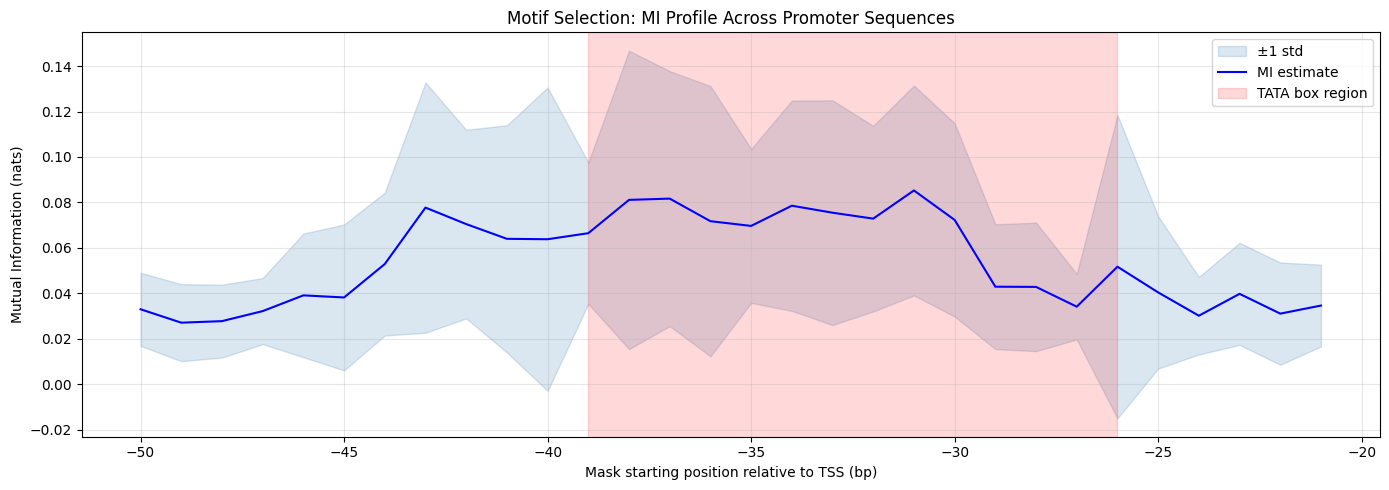

In [61]:
from matplotlib import pyplot as plt

USE_HF_DOWNLOAD = False  # Set to True to use motif_selection_mi_estimates_hf.txt instead of motif_selection.txt

if USE_HF_DOWNLOAD:
    motif_output_path = "motif_selection_mi_estimates_hf.txt"

with open(motif_output_path, 'r') as f:
    lines = f.readlines()
    positions = []
    mutinfos = []
    mutinfos_std = []
    for line in lines:
        pos, mi, mi_std = line.strip().split()
        positions.append(int(pos))
        mutinfos.append(float(mi))
        mutinfos_std.append(float(mi_std))

start = positions[0]
end = positions[-1] + 1
# Plot motif selection results
positions = list(range(start-200, end-200))

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(positions,
                [m - s for m, s in zip(mutinfos, mutinfos_std)],
                [m + s for m, s in zip(mutinfos, mutinfos_std)],
                alpha=0.2, color='steelblue', label='±1 std')
ax.plot(positions, mutinfos, 'b-', linewidth=1.5, label='MI estimate')

ax.axvspan(-39, -26, alpha=0.15, color='red', label='TATA box region')

ax.set_xlabel('Mask starting position relative to TSS (bp)')
ax.set_ylabel('Mutual Information (nats)')
ax.set_title('Motif Selection: MI Profile Across Promoter Sequences')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()